# Seleção de meta-features

## Algoritmo Genético

In [3]:
import numpy as np
import pandas as pd
import warnings
import threading
import matplotlib.pyplot as plt

from dataclasses import dataclass
from joblib import Parallel, delayed

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [4]:
@dataclass(frozen=True)
class GAConfig:
    name: str = "AG"
    target_col: str = "Best"
    population_size: int = 40
    generations: int = 60
    elitism: int = 4
    tournament_size: int = 4
    crossover_rate: float = 0.85
    mutation_start: float = 0.08
    mutation_end: float = 0.015
    init_min_prob: float = 0.05
    init_max_prob: float = 0.30
    parsimony_weight: float = 0.08
    parsimony_power: float = 1.25
    stability_weight: float = 0.10
    cv_splits: int = 5
    scoring: str = "f1_weighted"
    patience: int = 15
    immigrant_rate: float = 0.12
    local_search_rounds: int = 4
    local_search_add_candidates: int = 25
    min_samples_per_class: int = 2
    hard_max_features: int | None = None
    initialization_strategy: str = "guided"
    crossover_mode: str = "uniform"
    mutation_mode: str = "remove_bias"
    use_local_search: bool = True
    sparse_target_ratio: float = 0.12
    n_jobs: int = -1
    random_state: int = 42


@dataclass(frozen=True)
class Score:
    fitness: float
    f1_mean: float
    f1_std: float
    n_features: int


@dataclass
class GAResult:
    name: str
    selected_features: list
    selected_mask: np.ndarray
    fitness: float
    f1_mean: float
    f1_std: float
    n_features: int
    history: pd.DataFrame
    model: object | None = None
    last_error: object | None = None
    config: GAConfig | None = None

In [5]:
meta_dataset = pd.read_csv("C:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\article\src\data\metafeatures_dataset_with_best.csv")

classifier_cols = [c for c in meta_dataset.columns if c in ['DecisionTree', 'SVM', 'KNN',
                                                           'LogisticRegression', 'Perceptron', 'MLP']]
meta_feature_cols = [c for c in meta_dataset.columns if c not in ['Dataset', 'Best'] + classifier_cols]

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1337620821.py, line 1)

In [ ]:
base_config = GAConfig()

feature_cols = list(meta_feature_cols)

missing_features = [col for col in feature_cols if col not in meta_dataset.columns]

if missing_features:
    raise ValueError(f"As seguintes features não existem em meta_dataset: {missing_features}")

if base_config.target_col not in meta_dataset.columns:
    raise ValueError(f"A coluna alvo '{base_config.target_col}' não existe em meta_dataset.")

target_raw = meta_dataset[base_config.target_col].copy()

valid_target_mask = target_raw.notna()
dataset_ga = meta_dataset.loc[valid_target_mask].copy()
target_raw = dataset_ga[base_config.target_col].copy()

class_counts_before = target_raw.value_counts()

valid_classes = class_counts_before[
    class_counts_before >= base_config.min_samples_per_class
].index

rare_classes = class_counts_before[
    class_counts_before < base_config.min_samples_per_class
]

if len(rare_classes) > 0:
    print("Classes removidas por terem poucas amostras:")
    print(rare_classes)
    print("-" * 90)

dataset_ga = dataset_ga[
    dataset_ga[base_config.target_col].isin(valid_classes)
].copy()

X_df = dataset_ga[feature_cols].reset_index(drop=True)
y = dataset_ga[base_config.target_col].reset_index(drop=True)

import hashlib


@dataclass(frozen=True)
class FeatureFilterConfig:
    missing_threshold: float = 0.60
    quasi_constant_threshold: float = 0.98
    correlation_threshold: float = 0.985
    use_correlation_filter: bool = True


filter_config = FeatureFilterConfig(
    missing_threshold=0.60,
    quasi_constant_threshold=0.98,
    correlation_threshold=0.985,
    use_correlation_filter=True
)


def column_fingerprint(series):
    values = series.astype("string").fillna("__missing__")
    hashes = pd.util.hash_pandas_object(values, index=False).to_numpy(dtype=np.uint64)
    return hashlib.blake2b(hashes.tobytes(), digest_size=16).hexdigest()


def filter_features_unsupervised(X_df, config):
    X = X_df.copy()
    report = []

    initial_features = X.shape[1]

    missing_ratio = X.isna().mean()
    cols_high_missing = missing_ratio[missing_ratio > config.missing_threshold].index.tolist()
    X = X.drop(columns=cols_high_missing)

    report.append({
        "etapa": "Muitos valores ausentes",
        "removidas": len(cols_high_missing),
        "restantes": X.shape[1]
    })

    nunique = X.nunique(dropna=True)
    cols_constant = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=cols_constant)

    report.append({
        "etapa": "Constantes",
        "removidas": len(cols_constant),
        "restantes": X.shape[1]
    })

    cols_quasi_constant = []

    for col in X.columns:
        freq = X[col].value_counts(dropna=False, normalize=True)

        if len(freq) > 0 and freq.iloc[0] >= config.quasi_constant_threshold:
            cols_quasi_constant.append(col)

    X = X.drop(columns=cols_quasi_constant)

    report.append({
        "etapa": "Quase constantes",
        "removidas": len(cols_quasi_constant),
        "restantes": X.shape[1]
    })

    seen = {}
    cols_duplicate = []

    for col in X.columns:
        fp = column_fingerprint(X[col])

        if fp in seen:
            base_col = seen[fp]

            s1 = X[col].astype("string").fillna("__missing__")
            s2 = X[base_col].astype("string").fillna("__missing__")

            if s1.equals(s2):
                cols_duplicate.append(col)
        else:
            seen[fp] = col

    X = X.drop(columns=cols_duplicate)

    report.append({
        "etapa": "Duplicadas",
        "removidas": len(cols_duplicate),
        "restantes": X.shape[1]
    })

    cols_correlated = []

    if config.use_correlation_filter:
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

        if len(numeric_cols) > 1:
            X_num = X[numeric_cols].copy()
            X_num = X_num.apply(pd.to_numeric, errors="coerce")
            X_num = X_num.fillna(X_num.median(numeric_only=True))
            X_num = X_num.fillna(0)

            corr = X_num.corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

            cols_correlated = [
                col for col in upper.columns
                if any(upper[col] > config.correlation_threshold)
            ]

            X = X.drop(columns=cols_correlated)

    report.append({
        "etapa": "Alta correlação numérica",
        "removidas": len(cols_correlated),
        "restantes": X.shape[1]
    })

    report_df = pd.DataFrame(report)

    removed_features = list(set(X_df.columns) - set(X.columns))

    summary = {
        "features_iniciais": initial_features,
        "features_finais": X.shape[1],
        "features_removidas": len(removed_features),
        "removed_features": removed_features,
        "report": report_df
    }

    return X, summary


X_df, filter_summary = filter_features_unsupervised(
    X_df=X_df,
    config=filter_config
)

feature_cols = list(X_df.columns)
n_total_features = len(feature_cols)

print("Resumo da filtragem inicial:")
print(filter_summary["report"])
print("-" * 90)
print(f"Features antes: {filter_summary['features_iniciais']}")
print(f"Features depois: {filter_summary['features_finais']}")
print(f"Features removidas: {filter_summary['features_removidas']}")

class_counts = y.value_counts()

if y.nunique() < 2:
    raise ValueError(
        "Após remover classes raras, sobrou apenas uma classe em 'Best'. "
        "Não é possível treinar um classificador supervisionado."
    )

min_class_count = int(class_counts.min())
cv_splits = min(base_config.cv_splits, min_class_count)

if cv_splits < 2:
    raise ValueError(
        "Não há amostras suficientes para validação cruzada. "
        "Você precisa de pelo menos 2 amostras por classe."
    )

n_total_features = len(feature_cols)

cv = StratifiedKFold(
    n_splits=cv_splits,
    shuffle=True,
    random_state=base_config.random_state
)

print("Distribuição original das classes:")
print(class_counts_before)

print("\nDistribuição usada no AG:")
print(class_counts)

print(f"\nCV ajustado para {cv_splits} folds.")
print(f"Features totais: {n_total_features}")
print(f"Amostras usadas: {len(X_df)}")
print("-" * 90)

Classes removidas por terem poucas amostras:
Best
Perceptron    1
Name: count, dtype: int64
------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Resumo da filtragem inicial:
                      etapa  removidas  restantes
0   Muitos valores ausentes         10       1375
1                Constantes         36       1339
2          Quase constantes         13       1326
3                Duplicadas        190       1136
4  Alta correlação numérica        146        990
------------------------------------------------------------------------------------------
Features antes: 1385
Features depois: 990
Features removidas: 395
Distribuição original das classes:
Best
LogisticRegression    39
DecisionTree          22
SVM                   14
MLP                   10
KNN                    8
Perceptron             1
Name: count, dtype: int64

Distribuição usada no AG:
Best
LogisticRegression    39
DecisionTree          22
SVM                   14
MLP                   10
KNN                    8
Name: count, dtype: int64

CV ajustado para 5 folds.
Features totais: 990
Amostras usadas: 93
-----------------------------------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
base_estimator = ExtraTreesClassifier(
    n_estimators=180,
    max_features="sqrt",
    class_weight="balanced",
    random_state=base_config.random_state,
    n_jobs=1
)


def build_pipeline():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number))
        ],
        remainder="drop"
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(base_estimator))
    ])

In [ ]:
def compute_feature_ranking(X_df, y, feature_cols, random_state=42):
    rng = np.random.default_rng(random_state)
    scores = np.zeros(len(feature_cols), dtype=float)

    for i, col in enumerate(feature_cols):
        s = X_df[col]

        try:
            if pd.api.types.is_numeric_dtype(s):
                s_num = pd.to_numeric(s, errors="coerce")
                median_value = s_num.median()

                if pd.isna(median_value):
                    median_value = 0.0

                arr = s_num.fillna(median_value).to_numpy().reshape(-1, 1)
                discrete = False
            else:
                arr = (
                    s.astype("string")
                    .fillna("__missing__")
                    .astype("category")
                    .cat.codes
                    .to_numpy()
                    .reshape(-1, 1)
                )
                discrete = True

            score = mutual_info_classif(
                arr,
                y,
                discrete_features=discrete,
                random_state=random_state
            )[0]

            scores[i] = 0.0 if np.isnan(score) else score

        except Exception:
            scores[i] = 0.0

    ranking = np.argsort(scores)[::-1]

    if np.all(scores == 0):
        ranking = rng.permutation(len(feature_cols))

    ranking_df = pd.DataFrame({
        "feature": feature_cols,
        "filter_score": scores
    }).sort_values("filter_score", ascending=False)

    return ranking, scores, ranking_df


feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
    X_df=X_df,
    y=y,
    feature_cols=feature_cols,
    random_state=base_config.random_state
)

feature_ranking_df.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,feature,filter_score
895,tree_shape.quantiles.1,0.300933
570,median.histogram.9,0.291926
580,min.histogram.9,0.260290
896,tree_shape.quantiles.3,0.252680
878,tree_imbalance.min,0.246068
314,h_mean.histogram.9,0.244655
548,max.quantiles.1,0.229725
80,class_conc.histogram.0,0.229394
915,var.histogram.0,0.226910
955,wg_dist.max,0.217015


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
use_supervised_prefilter = True

supervised_top_k = min(150, n_total_features)

if use_supervised_prefilter:
    selected_prefilter_features = (
        feature_ranking_df
        .head(supervised_top_k)["feature"]
        .tolist()
    )

    X_df = X_df[selected_prefilter_features].copy()
    feature_cols = list(X_df.columns)
    n_total_features = len(feature_cols)

    feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        random_state=base_config.random_state
    )

    print(f"Filtro supervisionado aplicado.")
    print(f"Top-k usado: {supervised_top_k}")
    print(f"Features restantes: {n_total_features}")
else:
    print("Filtro supervisionado não aplicado.")

Filtro supervisionado aplicado.
Top-k usado: 150
Features restantes: 150


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
class GeneticFeatureSelector:
    def __init__(
        self,
        X_df,
        y,
        feature_cols,
        feature_ranking,
        pipeline_factory,
        cv,
        config
    ):
        self.X_df = X_df
        self.y = y
        self.feature_cols = list(feature_cols)
        self.feature_ranking = np.asarray(feature_ranking)
        self.pipeline_factory = pipeline_factory
        self.cv = cv
        self.config = config
        self.rng = np.random.default_rng(config.random_state)
        self.n_total_features = len(feature_cols)
        self.fitness_cache = {}
        self.cache_lock = threading.Lock()
        self.last_error = None

        self.rank_position = np.empty(self.n_total_features, dtype=int)
        self.rank_position[self.feature_ranking] = np.arange(self.n_total_features)

    def individual_key(self, individual):
        return np.packbits(individual.astype(np.uint8)).tobytes()

    def repair(self, individual):
        individual = individual.astype(np.uint8, copy=True)

        if individual.sum() == 0:
            individual[self.feature_ranking[0]] = 1

        if self.config.hard_max_features is not None and individual.sum() > self.config.hard_max_features:
            selected = np.flatnonzero(individual)
            selected_sorted = selected[np.argsort(self.rank_position[selected])]
            keep = selected_sorted[:self.config.hard_max_features]
            individual[:] = 0
            individual[keep] = 1

        return individual

    def evaluate_individual(self, individual):
        individual = self.repair(individual)
        key = self.individual_key(individual)

        with self.cache_lock:
            cached = self.fitness_cache.get(key)

        if cached is not None:
            return cached

        selected_idx = np.flatnonzero(individual)
        n_features = len(selected_idx)

        if n_features == 0:
            score = Score(-1e9, 0.0, 0.0, 0)

            with self.cache_lock:
                self.fitness_cache[key] = score

            return score

        selected_cols = [self.feature_cols[i] for i in selected_idx]
        X_subset = self.X_df[selected_cols]

        try:
            model = self.pipeline_factory()

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                fold_scores = cross_val_score(
                    model,
                    X_subset,
                    self.y,
                    cv=self.cv,
                    scoring=self.config.scoring,
                    n_jobs=1,
                    error_score=0.0
                )

            f1_mean = float(np.mean(fold_scores))
            f1_std = float(np.std(fold_scores))

            size_ratio = n_features / self.n_total_features
            size_penalty = self.config.parsimony_weight * (size_ratio ** self.config.parsimony_power)
            stability_penalty = self.config.stability_weight * f1_std

            fitness_value = f1_mean - size_penalty - stability_penalty

            score = Score(
                fitness=fitness_value,
                f1_mean=f1_mean,
                f1_std=f1_std,
                n_features=n_features
            )

        except Exception as exc:
            self.last_error = exc

            score = Score(
                fitness=-1e9,
                f1_mean=0.0,
                f1_std=0.0,
                n_features=n_features
            )

        with self.cache_lock:
            self.fitness_cache[key] = score

        return score

    def evaluate_population(self, population):
        return Parallel(
            n_jobs=self.config.n_jobs,
            prefer="threads"
        )(
            delayed(self.evaluate_individual)(ind) for ind in population
        )

    def random_individual(self):
        prob = self.rng.uniform(self.config.init_min_prob, self.config.init_max_prob)
        individual = (self.rng.random(self.n_total_features) < prob).astype(np.uint8)
        return self.repair(individual)

    def top_k_individual(self, k):
        individual = np.zeros(self.n_total_features, dtype=np.uint8)
        k = max(1, min(k, self.n_total_features))
        individual[self.feature_ranking[:k]] = 1
        return self.repair(individual)

    def initialize_population(self):
        population = []
        seen = set()

        if self.config.initialization_strategy in ["guided", "mixed"]:
            seed_sizes = [
                1,
                2,
                3,
                5,
                8,
                13,
                max(1, self.n_total_features // 20),
                max(1, self.n_total_features // 10),
                max(1, self.n_total_features // 5)
            ]

            for k in seed_sizes:
                ind = self.top_k_individual(k)
                key = self.individual_key(ind)

                if key not in seen:
                    population.append(ind)
                    seen.add(key)

        attempts = 0
        max_attempts = self.config.population_size * 200

        while len(population) < self.config.population_size and attempts < max_attempts:
            ind = self.random_individual()
            key = self.individual_key(ind)

            if key not in seen:
                population.append(ind)
                seen.add(key)

            attempts += 1

        while len(population) < self.config.population_size:
            population.append(self.random_individual())

        return population[:self.config.population_size]

    def tournament_select(self, population, scores):
        candidates = self.rng.choice(
            len(population),
            size=min(self.config.tournament_size, len(population)),
            replace=False
        )

        best_idx = max(
            candidates,
            key=lambda idx: (
                scores[idx].fitness,
                scores[idx].f1_mean,
                -scores[idx].n_features
            )
        )

        return population[best_idx].copy()

    def crossover(self, parent1, parent2):
        if self.rng.random() > self.config.crossover_rate:
            return parent1.copy(), parent2.copy()

        if self.config.crossover_mode == "one_point" and self.n_total_features > 1:
            point = self.rng.integers(1, self.n_total_features)

            child1 = np.concatenate([parent1[:point], parent2[point:]]).astype(np.uint8)
            child2 = np.concatenate([parent2[:point], parent1[point:]]).astype(np.uint8)

        else:
            mask = self.rng.random(self.n_total_features) < 0.5

            child1 = np.where(mask, parent1, parent2).astype(np.uint8)
            child2 = np.where(mask, parent2, parent1).astype(np.uint8)

        return self.repair(child1), self.repair(child2)

    def mutate(self, individual, generation):
        progress = generation / max(1, self.config.generations - 1)
        mutation_prob = self.config.mutation_start * (1.0 - progress) + self.config.mutation_end * progress

        individual = individual.copy()

        if self.config.mutation_mode == "flip":
            flip_mask = self.rng.random(self.n_total_features) < mutation_prob
            individual[flip_mask] = 1 - individual[flip_mask]

        elif self.config.mutation_mode == "sparse_adaptive":
            selected = individual == 1
            not_selected = individual == 0

            target_features = self.config.hard_max_features

            if target_features is None:
                target_features = max(1, int(self.n_total_features * self.config.sparse_target_ratio))

            current_features = int(individual.sum())

            if current_features > target_features:
                remove_factor = 2.00
                add_factor = 0.30
            else:
                remove_factor = 1.10
                add_factor = 0.70

            remove_mask = selected & (self.rng.random(self.n_total_features) < mutation_prob * remove_factor)
            add_mask = not_selected & (self.rng.random(self.n_total_features) < mutation_prob * add_factor)

            individual[remove_mask] = 0
            individual[add_mask] = 1

        else:
            selected = individual == 1
            not_selected = individual == 0

            remove_mask = selected & (self.rng.random(self.n_total_features) < mutation_prob * 1.25)
            add_mask = not_selected & (self.rng.random(self.n_total_features) < mutation_prob * 0.65)

            individual[remove_mask] = 0
            individual[add_mask] = 1

        return self.repair(individual)

    def is_better(self, new_score, old_score, eps=1e-8):
        if new_score.fitness > old_score.fitness + eps:
            return True

        if abs(new_score.fitness - old_score.fitness) <= eps:
            if new_score.f1_mean > old_score.f1_mean + eps:
                return True

            if abs(new_score.f1_mean - old_score.f1_mean) <= eps:
                return new_score.n_features < old_score.n_features

        return False

    def local_search(self, best_individual, best_score):
        current = best_individual.copy()
        current_score = best_score

        for _ in range(self.config.local_search_rounds):
            candidates = []
            selected = np.flatnonzero(current)

            if len(selected) > 1:
                for idx in selected:
                    candidate = current.copy()
                    candidate[idx] = 0
                    candidates.append(self.repair(candidate))

            add_pool = [idx for idx in self.feature_ranking if current[idx] == 0]
            add_pool = add_pool[:self.config.local_search_add_candidates]

            for idx in add_pool:
                candidate = current.copy()
                candidate[idx] = 1
                candidates.append(self.repair(candidate))

            if not candidates:
                break

            candidate_scores = self.evaluate_population(candidates)

            best_candidate_idx = max(
                range(len(candidates)),
                key=lambda i: (
                    candidate_scores[i].fitness,
                    candidate_scores[i].f1_mean,
                    -candidate_scores[i].n_features
                )
            )

            candidate = candidates[best_candidate_idx]
            candidate_score = candidate_scores[best_candidate_idx]

            if self.is_better(candidate_score, current_score):
                current = candidate
                current_score = candidate_score
            else:
                break

        return current, current_score

    def fit(self, verbose=True):
        population = self.initialize_population()
        scores = self.evaluate_population(population)

        history = []

        best_global = None
        best_global_score = Score(-1e9, 0.0, 0.0, 0)
        no_improvement = 0

        if verbose:
            print("=" * 90)
            print(self.config.name)
            print("=" * 90)
            print(f"População: {self.config.population_size}")
            print(f"Gerações máximas: {self.config.generations}")
            print(f"Scoring: {self.config.scoring}")
            print(f"Inicialização: {self.config.initialization_strategy}")
            print(f"Crossover: {self.config.crossover_mode}")
            print(f"Mutação: {self.config.mutation_mode}")
            print(f"Busca local: {self.config.use_local_search}")
            print("-" * 90)

        for gen in range(self.config.generations):
            ranked_idx = sorted(
                range(len(population)),
                key=lambda i: (
                    scores[i].fitness,
                    scores[i].f1_mean,
                    -scores[i].n_features
                ),
                reverse=True
            )

            current_best = population[ranked_idx[0]].copy()
            current_score = scores[ranked_idx[0]]

            if self.is_better(current_score, best_global_score):
                best_global = current_best.copy()
                best_global_score = current_score
                no_improvement = 0
            else:
                no_improvement += 1

            history.append({
                "generation": gen,
                "fitness": best_global_score.fitness,
                "f1_mean": best_global_score.f1_mean,
                "f1_std": best_global_score.f1_std,
                "n_features": best_global_score.n_features,
                "cache_size": len(self.fitness_cache)
            })

            if verbose:
                print(
                    f"Geração {gen:03d} | "
                    f"F1: {best_global_score.f1_mean:.5f} ± {best_global_score.f1_std:.5f} | "
                    f"Features: {best_global_score.n_features}/{self.n_total_features} | "
                    f"Fitness: {best_global_score.fitness:.5f} | "
                    f"Sem melhora: {no_improvement}/{self.config.patience}"
                )

            if no_improvement >= self.config.patience:
                if verbose:
                    print("-" * 90)
                    print(f"Early stopping ativado na geração {gen}.")

                break

            new_population = [population[i].copy() for i in ranked_idx[:self.config.elitism]]

            immigrant_count = max(1, int(self.config.population_size * self.config.immigrant_rate))
            child_limit = self.config.population_size - immigrant_count

            while len(new_population) < child_limit:
                parent1 = self.tournament_select(population, scores)
                parent2 = self.tournament_select(population, scores)

                child1, child2 = self.crossover(parent1, parent2)

                child1 = self.mutate(child1, gen)
                child2 = self.mutate(child2, gen)

                new_population.append(child1)

                if len(new_population) < child_limit:
                    new_population.append(child2)

            while len(new_population) < self.config.population_size:
                new_population.append(self.random_individual())

            population = new_population[:self.config.population_size]
            scores = self.evaluate_population(population)

        if self.config.use_local_search:
            if verbose:
                print("-" * 90)
                print("Aplicando busca local final...")

            best_global, best_global_score = self.local_search(best_global, best_global_score)

        selected_idx = np.flatnonzero(best_global)
        final_features = [self.feature_cols[i] for i in selected_idx]

        if verbose:
            print("-" * 90)
            print("RESULTADO FINAL")
            print(f"Features selecionadas: {best_global_score.n_features}/{self.n_total_features}")
            print(f"F1 estimado: {best_global_score.f1_mean:.5f} ± {best_global_score.f1_std:.5f}")
            print(f"Fitness final: {best_global_score.fitness:.5f}")
            print("Atributos selecionados:")
            print(final_features)

            if self.last_error is not None and best_global_score.f1_mean == 0.0:
                print("Último erro capturado durante avaliação:")
                print(repr(self.last_error))

        return GAResult(
            name=self.config.name,
            selected_features=final_features,
            selected_mask=best_global,
            fitness=best_global_score.fitness,
            f1_mean=best_global_score.f1_mean,
            f1_std=best_global_score.f1_std,
            n_features=best_global_score.n_features,
            history=pd.DataFrame(history),
            last_error=self.last_error,
            config=self.config
        )

In [ ]:
hard_max_features_compact = max(
    1,
    min(
        n_total_features,
        max(5, n_total_features // 8)
    )
)

ga_configs = [
    GAConfig(
        name="AG 1 - Clássico binário",
        target_col=base_config.target_col,
        population_size=80,
        generations=150,
        elitism=4,
        tournament_size=4,
        crossover_rate=0.85,
        mutation_start=0.10,
        mutation_end=0.02,
        init_min_prob=0.08,
        init_max_prob=0.40,
        parsimony_weight=0.04,
        parsimony_power=1.10,
        stability_weight=0.05,
        cv_splits=cv_splits,
        scoring="f1_weighted",
        patience=25,
        immigrant_rate=0.08,
        hard_max_features=None,
        initialization_strategy="random",
        crossover_mode="one_point",
        mutation_mode="flip",
        use_local_search=False,
        n_jobs=-1,
        random_state=42
    ),

    GAConfig(
        name="AG 2 - Guiado por MI + busca local",
        target_col=base_config.target_col,
        population_size=80,
        generations=150,
        elitism=4,
        tournament_size=4,
        crossover_rate=0.85,
        mutation_start=0.08,
        mutation_end=0.015,
        init_min_prob=0.05,
        init_max_prob=0.30,
        parsimony_weight=0.08,
        parsimony_power=1.25,
        stability_weight=0.10,
        cv_splits=cv_splits,
        scoring="f1_weighted",
        patience=25,
        immigrant_rate=0.12,
        local_search_rounds=4,
        local_search_add_candidates=25,
        hard_max_features=None,
        initialization_strategy="guided",
        crossover_mode="uniform",
        mutation_mode="remove_bias",
        use_local_search=True,
        n_jobs=-1,
        random_state=42
    ),

    GAConfig(
        name="AG 3 - Compacto/esparso",
        target_col=base_config.target_col,
        population_size=80,
        generations=150,
        elitism=5,
        tournament_size=5,
        crossover_rate=0.90,
        mutation_start=0.10,
        mutation_end=0.01,
        init_min_prob=0.03,
        init_max_prob=0.18,
        parsimony_weight=0.16,
        parsimony_power=1.50,
        stability_weight=0.12,
        cv_splits=cv_splits,
        scoring="f1_weighted",
        patience=25,
        immigrant_rate=0.15,
        local_search_rounds=5,
        local_search_add_candidates=30,
        hard_max_features=hard_max_features_compact,
        initialization_strategy="guided",
        crossover_mode="uniform",
        mutation_mode="sparse_adaptive",
        use_local_search=True,
        sparse_target_ratio=0.10,
        n_jobs=-1,
        random_state=42
    )
]

In [ ]:
results = []

for cfg in ga_configs:
    selector = GeneticFeatureSelector(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        feature_ranking=feature_ranking,
        pipeline_factory=build_pipeline,
        cv=cv,
        config=cfg
    )

    result = selector.fit(verbose=True)

    final_model = build_pipeline()
    final_model.fit(X_df[result.selected_features], y)

    result.model = final_model

    results.append(result)

AG 1 - Clássico binário
População: 80
Gerações máximas: 150
Scoring: f1_weighted
Inicialização: random
Crossover: one_point
Mutação: flip
Busca local: False
------------------------------------------------------------------------------------------
Geração 000 | F1: 0.59551 ± 0.13076 | Features: 48/150 | Fitness: 0.57755 | Sem melhora: 0/25
Geração 001 | F1: 0.59551 ± 0.13076 | Features: 48/150 | Fitness: 0.57755 | Sem melhora: 1/25
Geração 002 | F1: 0.59652 ± 0.09829 | Features: 51/150 | Fitness: 0.57940 | Sem melhora: 0/25
Geração 003 | F1: 0.59652 ± 0.09829 | Features: 51/150 | Fitness: 0.57940 | Sem melhora: 1/25
Geração 004 | F1: 0.59652 ± 0.09829 | Features: 51/150 | Fitness: 0.57940 | Sem melhora: 2/25
Geração 005 | F1: 0.60969 ± 0.15035 | Features: 70/150 | Fitness: 0.58487 | Sem melhora: 0/25
Geração 006 | F1: 0.60969 ± 0.15035 | Features: 70/150 | Fitness: 0.58487 | Sem melhora: 1/25
Geração 007 | F1: 0.60969 ± 0.15035 | Features: 70/150 | Fitness: 0.58487 | Sem melhora: 2/25


In [ ]:
comparison_df = pd.DataFrame([
    {
        "metodo": result.name,
        "f1_mean": result.f1_mean,
        "f1_std": result.f1_std,
        "fitness": result.fitness,
        "n_features": result.n_features,
        "percentual_features": result.n_features / n_total_features,
        "features": result.selected_features
    }
    for result in results
]).sort_values(
    by=["f1_mean", "fitness", "n_features"],
    ascending=[False, False, True]
).reset_index(drop=True)

comparison_df

,metodo,f1_mean,f1_std,fitness,n_features,percentual_features,features
0,AG 3 - Compacto/esparso,0.696764,0.045049,0.684707,18,0.120000,"[tree_shape.quantiles.1, median.histogram.9, m..."
1,AG 2 - Guiado por MI + busca local,0.679258,0.101682,0.653760,40,0.266667,"[median.histogram.9, min.histogram.9, tree_imb..."
2,AG 1 - Clássico binário,0.641563,0.110128,0.619573,67,0.446667,"[tree_shape.quantiles.1, median.histogram.9, m..."


In [ ]:
best_result = max(
    results,
    key=lambda result: (
        result.f1_mean,
        result.fitness,
        -result.n_features
    )
)

result_ga = {
    "selected_features": best_result.selected_features,
    "selected_mask": best_result.selected_mask,
    "fitness": best_result.fitness,
    "f1_mean": best_result.f1_mean,
    "f1_std": best_result.f1_std,
    "n_features": best_result.n_features,
    "history": best_result.history,
    "model": best_result.model,
    "feature_filter_scores": feature_ranking_df,
    "class_counts_original": class_counts_before,
    "class_counts_used": class_counts,
    "comparison": comparison_df,
    "all_results": results
}

print("Melhor resultado por F1:")
print(best_result.name)
print("-" * 90)
print(f"F1 estimado: {best_result.f1_mean:.5f} ± {best_result.f1_std:.5f}")
print(f"Fitness: {best_result.fitness:.5f}")
print(f"Features selecionadas: {best_result.n_features}/{n_total_features}")
print("-" * 90)
print(best_result.selected_features)

Melhor resultado por F1:
AG 3 - Compacto/esparso
------------------------------------------------------------------------------------------
F1 estimado: 0.69676 ± 0.04505
Fitness: 0.68471
Features selecionadas: 18/150
------------------------------------------------------------------------------------------
['tree_shape.quantiles.1', 'median.histogram.9', 'min.histogram.9', 'tree_shape.quantiles.3', 'var.histogram.0', 'wg_dist.max', 'range.median', 'mad.histogram.0', 'sparsity.histogram.9', 'elite_nn.max', 'best_node.max', 'range.histogram.0', 'max.histogram.9', 'nr_attr', 'g_mean.histogram.9', 'one_nn.quantiles.1.relative', 'elite_nn.max.relative', 'min.max']


In [ ]:
for result in results:
    print("=" * 90)
    print(result.name)
    print(f"F1: {result.f1_mean:.5f} ± {result.f1_std:.5f}")
    print(f"Fitness: {result.fitness:.5f}")
    print(f"Features: {result.n_features}/{n_total_features}")
    print("-" * 90)

    for feature in result.selected_features:
        print(feature)

AG 1 - Clássico binário
F1: 0.64156 ± 0.11013
Fitness: 0.61957
Features: 67/150
------------------------------------------------------------------------------------------
tree_shape.quantiles.1
median.histogram.9
min.histogram.9
tree_shape.quantiles.3
h_mean.histogram.9
mad.histogram.0
sparsity.histogram.9
leaves_branch.quantiles.1
elite_nn.median
best_node.max
range.min
range.histogram.0
elite_nn.min
tree_depth.histogram.9
max.histogram.9
leaves_branch.sd
nr_attr
f3.mean
n2.histogram.7
mad.histogram.9
elite_nn.median.relative
tree_imbalance.quantiles.1
one_nn.quantiles.1.relative
elite_nn.max.relative
best_node.max.relative
leaves_homo.median
mean.median
impconceptvar.mean
one_nn.min
nodes_per_level.median
attr_ent.histogram.0
elite_nn.quantiles.1
mean.histogram.9
max.min
f3.min
sparsity.histogram.3
wg_dist.histogram.5
attr_ent.quantiles.1
joint_ent.histogram.0
one_nn.median.relative
random_node.histogram.9
f3.quantiles.1
leaves_branch.max
leaves_homo.min
nodes_per_inst
one_nn.mean
le

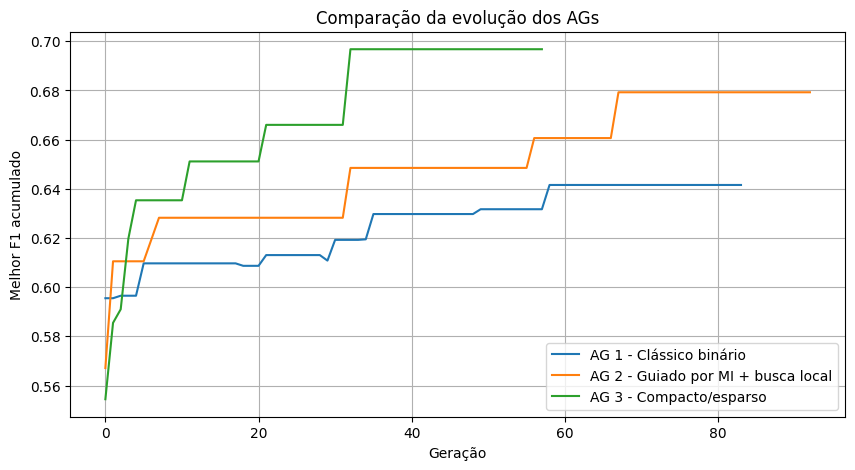

In [ ]:
plt.figure(figsize=(10, 5))

for result in results:
    plt.plot(
        result.history["generation"],
        result.history["f1_mean"],
        label=result.name
    )

plt.xlabel("Geração")
plt.ylabel("Melhor F1 acumulado")
plt.title("Comparação da evolução dos AGs")
plt.legend()
plt.grid(True)
plt.show()

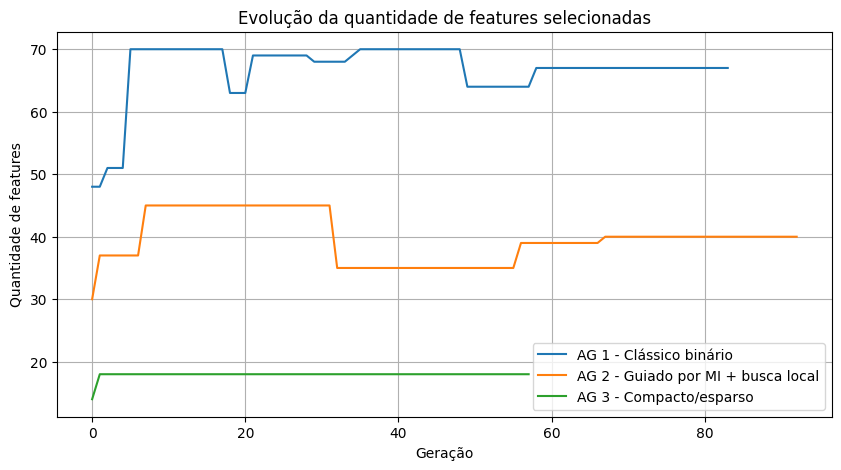

In [ ]:
plt.figure(figsize=(10, 5))

for result in results:
    plt.plot(
        result.history["generation"],
        result.history["n_features"],
        label=result.name
    )

plt.xlabel("Geração")
plt.ylabel("Quantidade de features")
plt.title("Evolução da quantidade de features selecionadas")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
comparison_df.to_csv("comparacao_algoritmos_geneticos_features.csv", index=False)

feature_ranking_df.to_csv("ranking_filtro_mutual_info.csv", index=False)

print("Arquivos exportados:")
print("comparacao_algoritmos_geneticos_features.csv")
print("ranking_filtro_mutual_info.csv")

Arquivos exportados:
comparacao_algoritmos_geneticos_features.csv
ranking_filtro_mutual_info.csv
